# Object Detection Project
**Name :** MITHUN S    **Reg. No :** 212224240088   **Slot No :** 26OD1199

# Object Detection Project

## Russian License Plate Blurring

Welcome to your object detection project! Your goal will be to use Haar Cascades to blur license plates detected in an image!

----


#### Ways to Approach this project:
* Use the given image (car_plate.jpg) and create a function that will blur the image of its license plate. Check out the correct pre-trained .xml file (given) to use.
* Use this notebook! Here we offer a guide of what main steps you should take to complete the project.


**TASK: Import the usual libraries you think you'll need.**

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**TASK: Read in the car_plate.jpg file from the repo.**

In [53]:
img = cv2.imread("car_plate.jpg")

**TASK: Create a function that displays the image in a larger scale and correct coloring for matplotlib.**

In [54]:
def display(img):
    # Convert BGR image to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

 # Display image
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

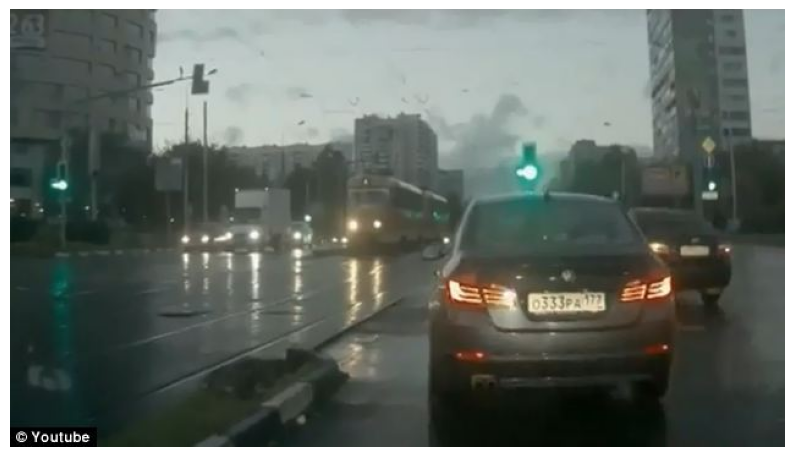

In [55]:
display(img)

**TASK: Load the haarcascade_russian_plate_number.xml file.**

In [56]:
plate_cascade = cv2.CascadeClassifier(
    "haarcascade_licence_plate_rus_16stages.xml"
)

**TASK: Create a function that takes in an image and draws a rectangle around what it detects to be a license plate. Keep in mind we're just drawing a rectangle around it for now, later on we'll adjust this function to blur. You may want to play with the scaleFactor and minNeighbor numbers to get good results.**

In [57]:
def detect_plate(img):
    
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect license plates
    plates = plate_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 20)
    )
    
    # Draw rectangle around each detected plate
    result = img.copy()
    
    for (x, y, w, h) in plates:
        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            3
        )
    
    return result, plates

In [58]:
result, plates = detect_plate(img)

print("Number of plates detected:", len(plates))

Number of plates detected: 0


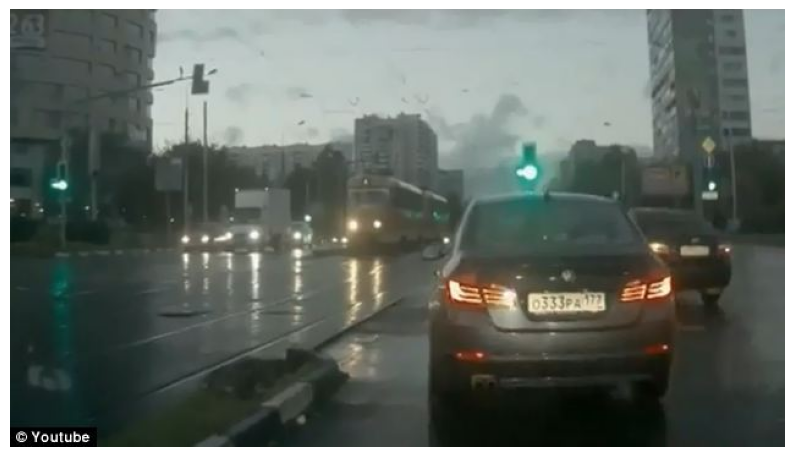

In [59]:
display(result)

**FINAL TASK: Edit the function so that is effectively blurs the detected plate, instead of just drawing a rectangle around it. Here are the steps you might want to take:**

1. The hardest part is converting the (x,y,w,h) information into the dimension values you need to grab an ROI. you just need to convert the information about the top left corner of the rectangle and width and height, into indexing position values.
2. Once you've grabbed the ROI using the (x,y,w,h) values returned, you'll want to blur that ROI. You can use cv2.medianBlur for this.
3. Now that you have a blurred version of the ROI (the license plate) you will want to paste this blurred image back on to the original image at the same original location. Simply using Numpy indexing and slicing to reassign that area of the original image to the blurred roi.

In [60]:
def detect_and_blur_plate(img):
    
    result = img.copy()
    
    # Convert to grayscale
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
    
    # Detect license plates
    plates = plate_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 20)
    )
    
    for (x, y, w, h) in plates:
        
        # Extract license plate ROI
        roi = result[y:y+h, x:x+w]
        
        # Blur the license plate
        blurred_roi = cv2.medianBlur(roi, 21)
        
        # Put blurred ROI back into image
        result[y:y+h, x:x+w] = blurred_roi
    
    return result

In [61]:
final_result = detect_and_blur_plate(img)

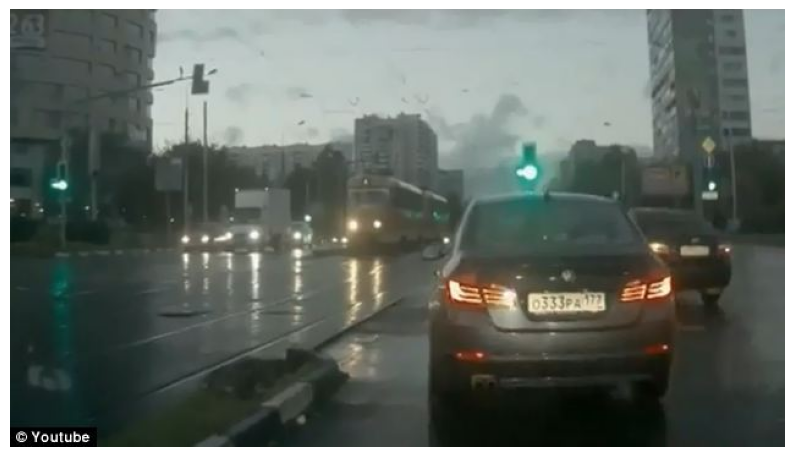

In [62]:
display(final_result)

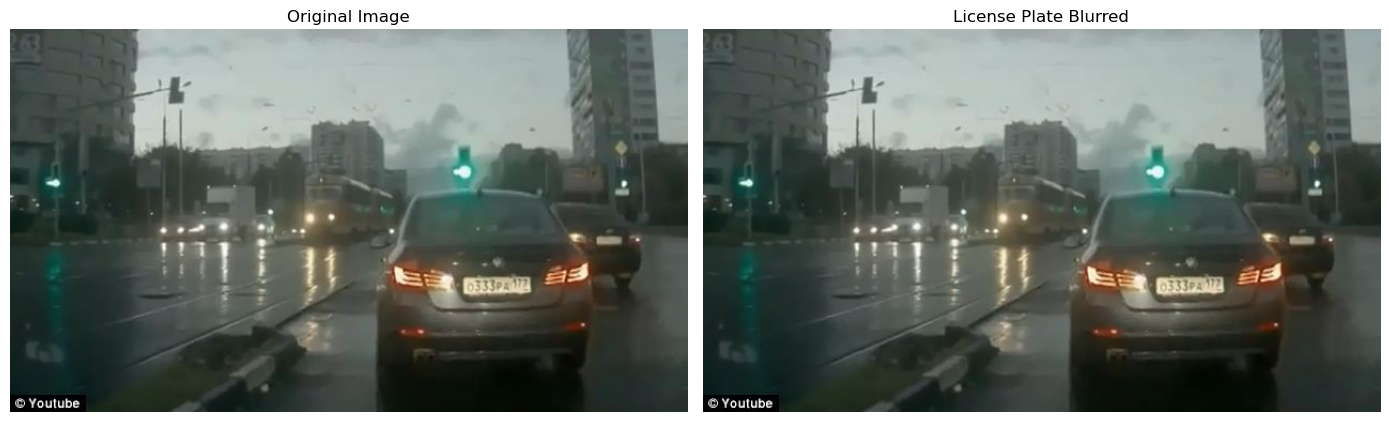

In [63]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
plt.title("License Plate Blurred")
plt.axis("off")

plt.tight_layout()
plt.show()

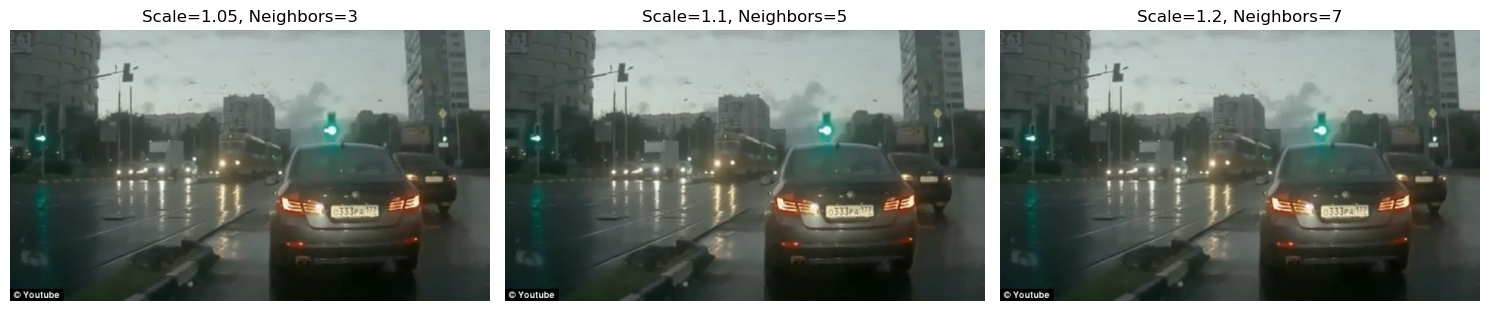

In [64]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

settings = [
    (1.05, 3),
    (1.10, 5),
    (1.20, 7)
]

plt.figure(figsize=(15, 5))

for i, (scale, neighbors) in enumerate(settings):
    
    plates = plate_cascade.detectMultiScale(
        gray,
        scaleFactor=scale,
        minNeighbors=neighbors,
        minSize=(50, 20)
    )
    
    result = img.copy()
    
    for (x, y, w, h) in plates:
        cv2.rectangle(
            result,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            3
        )
    
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Scale={scale}, Neighbors={neighbors}")
    plt.axis("off")

plt.tight_layout()
plt.show()